<a href="https://colab.research.google.com/github/AtharvRai67/task-6/blob/main/taskk12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Final Capstone & Career Preparation**

 Phase 1 : Project Setup

In [ ]:
# Import libraries
import pandas as pd
import numpy as np

from google.colab import files
uploaded = files.upload()


# Load dataset
# Make sure 'customer_churn (3).csv' is in the correct directory or provide the full path.
# If running in Google Colab, you might need to upload the file or mount Google Drive.
df = pd.read_csv("customer_churn (3).csv")

# Basic info
print(df.head())
print(df.info())
print(df.describe())

# Check missing values
print(df.isnull().sum())

Saving customer_churn (3).csv to customer_churn (3) (1).csv
  CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0     C00001       6              64          1540        One year   
1     C00002      21             113          1753  Month-to-month   
2     C00003      27              31          1455        Two year   
3     C00004      53              29          7150  Month-to-month   
4     C00005      16             185          1023        One year   

      PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0       Credit Card               No              1      0  
1  Electronic Check              Yes              1      0  
2       Credit Card               No              1      0  
3  Electronic Check               No              1      0  
4  Electronic Check               No              1      0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---

Data Collection & Understanding

In [ ]:
# Data dictionary view
for col in df.columns:
    print(col)

# Check unique values
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].unique())

# Check target distribution
print(df['Churn'].value_counts())

CustomerID
Tenure
MonthlyCharges
TotalCharges
Contract
PaymentMethod
PaperlessBilling
SeniorCitizen
Churn
CustomerID ['C00001' 'C00002' 'C00003' 'C00004' 'C00005' 'C00006' 'C00007' 'C00008'
 'C00009' 'C00010' 'C00011' 'C00012' 'C00013' 'C00014' 'C00015' 'C00016'
 'C00017' 'C00018' 'C00019' 'C00020' 'C00021' 'C00022' 'C00023' 'C00024'
 'C00025' 'C00026' 'C00027' 'C00028' 'C00029' 'C00030' 'C00031' 'C00032'
 'C00033' 'C00034' 'C00035' 'C00036' 'C00037' 'C00038' 'C00039' 'C00040'
 'C00041' 'C00042' 'C00043' 'C00044' 'C00045' 'C00046' 'C00047' 'C00048'
 'C00049' 'C00050' 'C00051' 'C00052' 'C00053' 'C00054' 'C00055' 'C00056'
 'C00057' 'C00058' 'C00059' 'C00060' 'C00061' 'C00062' 'C00063' 'C00064'
 'C00065' 'C00066' 'C00067' 'C00068' 'C00069' 'C00070' 'C00071' 'C00072'
 'C00073' 'C00074' 'C00075' 'C00076' 'C00077' 'C00078' 'C00079' 'C00080'
 'C00081' 'C00082' 'C00083' 'C00084' 'C00085' 'C00086' 'C00087' 'C00088'
 'C00089' 'C00090' 'C00091' 'C00092' 'C00093' 'C00094' 'C00095' 'C00096'
 'C0009

Exploratory Data Analysis (EDA)

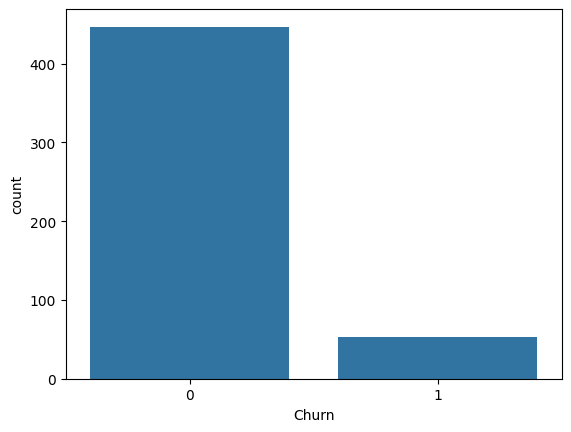

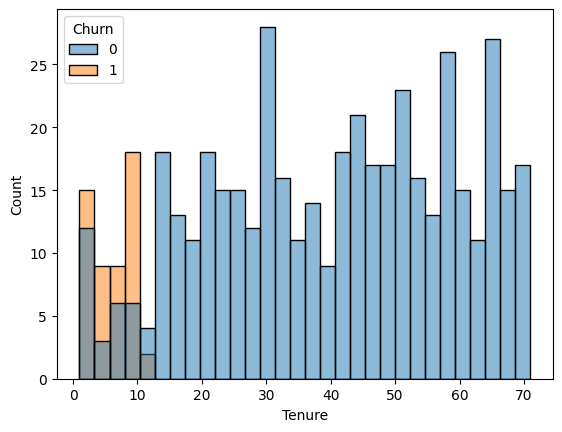

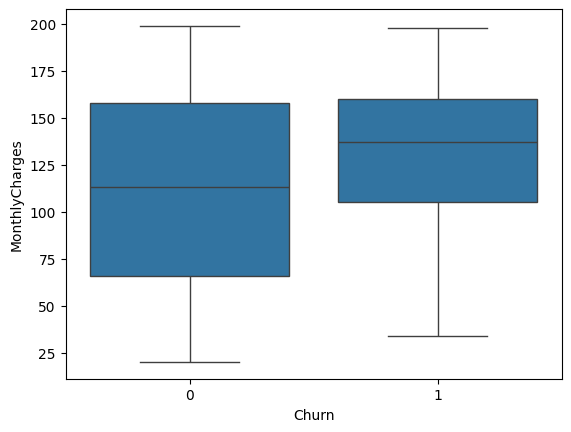

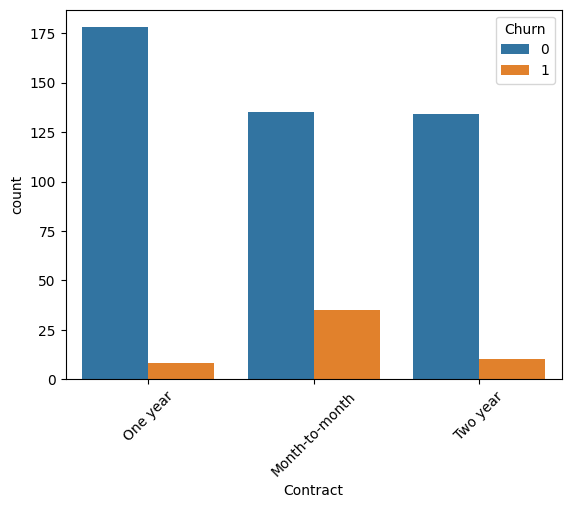

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Churn distribution
sns.countplot(x='Churn', data=df)
plt.show()

# Tenure vs Churn
sns.histplot(data=df, x='Tenure', hue='Churn', bins=30)
plt.show()

# Monthly Charges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

# Contract Type vs Churn
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

Data Preprocessing

In [ ]:
# Drop ID column
df = df.drop('CustomerID', axis=1)

# Convert categorical variables
df = pd.get_dummies(df, drop_first=True)

# Split data
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Models
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier()

# Train
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier()

Model Evaluation & Tuning

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Predictions
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

# Logistic Regression
print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# Random Forest
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# ROC-AUC
print("RF ROC-AUC:", roc_auc_score(y_test, y_pred_rf))

LR Accuracy: 0.96
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        84
           1       0.88      0.88      0.88        16

    accuracy                           0.96       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.96      0.96      0.96       100

RF Accuracy: 0.96
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        84
           1       0.93      0.81      0.87        16

    accuracy                           0.96       100
   macro avg       0.95      0.90      0.92       100
weighted avg       0.96      0.96      0.96       100

RF ROC-AUC: 0.9002976190476191


In [ ]:
#Optional Hyperparameter Tuning (Bonus)
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 20, 'n_estimators': 50}


Deployment (Flask API)

In [ ]:
# Save model
import pickle
pickle.dump(rf, open('model.pkl', 'wb'))

Flask App (app.py)

In [ ]:
from flask import Flask, request, jsonify
import pickle
import numpy as np

app = Flask(__name__)
model = pickle.load(open('model.pkl', 'rb'))

@app.route('/')
def home():
    return "Churn Prediction API Running"

@app.route('/predict', methods=['POST'])
def predict():
    data = request.json
    features = np.array(list(data.values())).reshape(1, -1)
    prediction = model.predict(features)
    return jsonify({'Churn': int(prediction[0])})

if __name__ == "__main__":
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


In [ ]:
#Documentation Code (Important Outputs)
# Feature importance (for report)
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [ ]:
#Career Prep (Final Summary Code)
# Final model summary
print("Final Model: Random Forest")
print("Features used:", list(X.columns))

# Save predictions
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_rf
})

results.to_csv("predictions.csv", index=False)